# ① LSTM 时序预测：完整实现 · 精度检验 · 调参 · 改进

> **数据-物理融合驱动的岩土工程风险评估 —— 算法系列 ①**
> 以边坡/库岸位移预测为示例任务（多变量驱动 → 未来位移速率 → 重构累积位移），流程同样适用于沉降、隧道收敛、渗压等岩土时序。

**目录**
1. 环境配置
2. 演示数据（含【替换为真实数据】接口）
3. 数据预处理（目标变换 / 防泄漏的标准化 / 滑窗 / 时序划分）
4. LSTM 原理与 NumPy 从零实现 + 数值梯度检查
5. PyTorch 模型（LSTM / GRU / BiLSTM 可切换）
6. 训练（EarlyStopping / LR 调度 / 梯度裁剪）
7. 精度检验（RMSE / MAE / MAPE / R² / NSE + 系列图 + 多步递归预测）
8. 调参（超参数清单 / 随机搜索 / Optuna）
9. 改进方向（累积位移三种处理对比、物理软约束融合、MC Dropout 不确定性、多种子集成）
10. 汇总与接入真实数据清单

**使用自己的数据**：只需一个 CSV（时间列 + 若干驱动列 + 1 个目标列），改 §2.2 的几个变量即可全流程复用。

In [1]:
import math, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# ---------- 全局随机种子（结果可复现）----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42

# ---------- 设备选择 ----------
# 本 Notebook 模型很小，CPU 已足够快；数据/模型变大后，Apple 芯片可改为 "mps"，NVIDIA 显卡改为 "cuda"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device = {DEVICE} | MPS available: {torch.backends.mps.is_available()}")

# ---------- 中文绘图（无中文字体时自动回退）----------
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# ---------- 日频时间轴防拥挤 ----------
import matplotlib.dates as mdates
def fix_date_axis(ax, max_ticks=7):
    loc = mdates.AutoDateLocator(minticks=3, maxticks=max_ticks)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

PyTorch 2.9.1 | device = cpu | MPS available: True


## 2. 演示数据（可整体替换为真实数据）

为让 Notebook 开箱即跑，先合成一条**贴近库岸边坡物理机制**的日尺度序列（约 6 年）：

$$v_t = \underbrace{v_0 e^{-t/T}}_{\text{蠕变衰减}} + \underbrace{a\cdot R^{eff}_t}_{\text{降雨响应(一阶滞后)}} + \underbrace{b\cdot \max(0,-\Delta L_t)}_{\text{库水位骤降响应}} + \varepsilon_t,\qquad D_t=\sum v_t$$

即：**累积位移单调增长、雨季呈台阶状**，这是三峡库区堆积层边坡的典型形态。合成数据的全部参数仅供演示，**正式研究请替换为监测数据**。

In [2]:
def make_synthetic_data(n_days=2190, start="2016-01-01", seed=0):
    """合成库岸边坡日尺度多变量序列（仅用于跑通流程）。"""
    rng = np.random.default_rng(seed)
    t = np.arange(n_days)
    doy = pd.date_range(start, periods=n_days).dayofyear.to_numpy()

    # 1) 降雨：雨季(5-9月)强 + 随机暴雨
    seasonal = 0.5 + 0.5 * np.cos(2 * np.pi * (doy - 200) / 365)      # 7-8 月峰值
    rain = rng.gamma(shape=0.9, scale=12.0, size=n_days) * seasonal
    storm = (rng.random(n_days) < 0.03) * rng.gamma(2.0, 60.0, size=n_days)
    rain = np.clip(rain + storm, 0, None)

    # 2) 库水位：145(夏)~175(冬) 年周期 + 小噪声
    level = 160 - 15 * np.cos(2 * np.pi * (doy - 105) / 365) + rng.normal(0, 0.4, n_days)
    dlevel = np.gradient(level)                                        # m/day（负值 = 骤降）

    # 3) 温度
    temp = 17 + 10 * np.sin(2 * np.pi * (doy - 100) / 365) + rng.normal(0, 1.5, n_days)

    # 4) 有效降雨：一阶指数滞后核（渗透滞后 τ=12 天，窗口 60 天）—— 常用的降雨-入渗响应简化
    tau, K = 12.0, 60
    w = np.exp(-np.arange(K) / tau); w /= w.sum()
    eff_rain = np.convolve(rain, w, mode="full")[:n_days]

    # 5) 位移速度 → 累积位移
    creep = 0.9 * np.exp(-t / 650.0)                # mm/day，随时间衰减的蠕变
    resp = 0.10 * eff_rain + 0.9 * np.clip(-dlevel, 0, None)
    vel = creep + resp + rng.normal(0, 0.15, n_days)
    disp = np.cumsum(np.clip(vel, 0, None))         # mm

    return pd.DataFrame({"date": pd.date_range(start, periods=n_days),
                         "rainfall_mm": rain, "reservoir_m": level,
                         "temp_c": temp, "disp_mm": disp})

df_raw = make_synthetic_data()
df_raw.to_csv("demo_geodata.csv", index=False)      # 存为 CSV，之后当作"真实数据"来读
print(df_raw.shape)
df_raw.head()

(2190, 5)


,date,rainfall_mm,reservoir_m,temp_c,disp_mm
0,2016-01-01,0.218364,163.551307,8.494965,2.162372
1,2016-01-02,0.336965,162.291151,8.501532,3.514549
2,2016-01-03,0.154186,162.138355,8.021471,4.401052
3,2016-01-04,0.110442,162.464550,7.617819,5.255903
4,2016-01-05,0.259013,162.133255,7.351304,6.229391


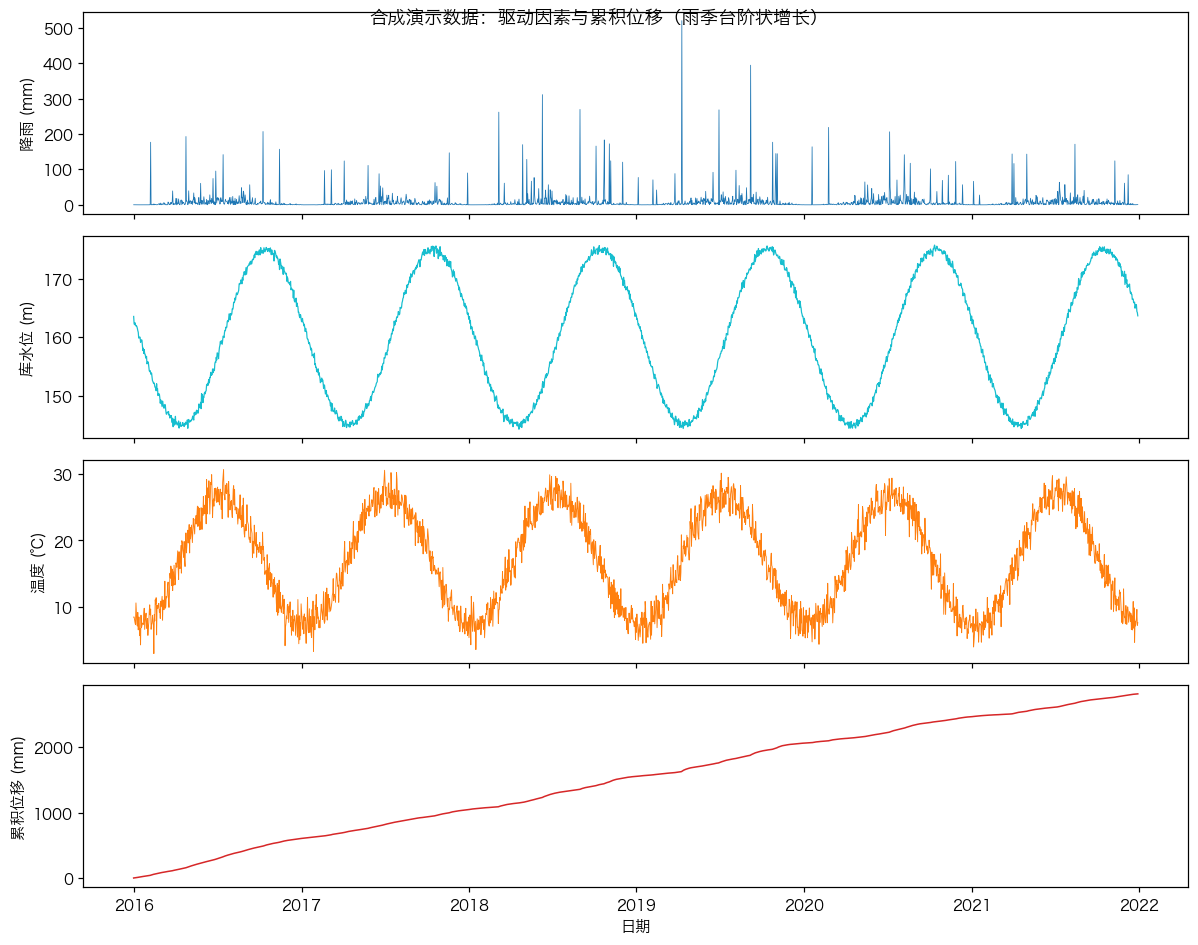

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(df_raw.date, df_raw.rainfall_mm, lw=.5, color="tab:blue");   axes[0].set_ylabel("降雨 (mm)")
axes[1].plot(df_raw.date, df_raw.reservoir_m, lw=.8, color="tab:cyan");   axes[1].set_ylabel("库水位 (m)")
axes[2].plot(df_raw.date, df_raw.temp_c, lw=.6, color="tab:orange");      axes[2].set_ylabel("温度 (℃)")
axes[3].plot(df_raw.date, df_raw.disp_mm, lw=1.0, color="tab:red");       axes[3].set_ylabel("累积位移 (mm)")
axes[3].set_xlabel("日期")
fig.suptitle("合成演示数据：驱动因素与累积位移（雨季台阶状增长）", y=0.95)
plt.tight_layout(); plt.show()

### 2.2 【替换为真实数据】只需改这一格

```python
DATA_PATH = "your_data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date")

# 位移/沉降类"持续增长"的目标：强烈建议预测速率(日增量)，再重构累积值（原因见 §3 与 §9.2）
df["disp_rate_mm"] = df["disp_mm"].diff()
df = df.dropna(subset=["disp_rate_mm"])

FEATURE_COLS = ["rainfall_mm", "reservoir_m", "temp_c", "disp_rate_mm"]   # ← 驱动特征
TARGET_COL   = "disp_rate_mm"                                             # ← 预测目标
```

**接入要求与建议**
- 时间**等间隔**（日/小时均可）；缺失值先插值（§3.1）；建议样本量 ≥ 500。
- 特征里**包含目标自身的滞后历史（自回归项）通常显著提升精度**——`FEATURE_COLS` 含 `disp_rate_mm` 即可；
  预测未来时历史速率是已观测的，递归多步预测时用模型预测值回填（§7.4 已实现）。
- 若驱动变量是"降雨/水位/温度"这类有预报或情景假设的量，多步预测时直接用预报值。

In [4]:
# ================== 配置区：换数据只改这里 ==================
DATA_PATH = "demo_geodata.csv"                                        # ← 换成你的 CSV

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df["disp_rate_mm"] = df["disp_mm"].diff()          # 位移速率 = 累积位移一阶差分（mm/day）
df = df.dropna(subset=["disp_rate_mm"]).reset_index(drop=True)

FEATURE_COLS = ["rainfall_mm", "reservoir_m", "temp_c", "disp_rate_mm"]   # ← 驱动特征（含目标自身 = 自回归）
TARGET_COL   = "disp_rate_mm"                                              # ← 预测目标：位移速率

SEQ_LEN, HORIZON    = 30, 1        # 回看窗口(天) / 预测步长
VAL_FRAC, TEST_FRAC = 0.15, 0.15   # 时序划分比例
BATCH_SIZE          = 64

print(f"样本数 = {len(df)}, 时间范围 = {df.date.iloc[0].date()} ~ {df.date.iloc[-1].date()}")
df[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]]

样本数 = 2189, 时间范围 = 2016-01-02 ~ 2021-12-29


,mean,std,min,max
rainfall_mm,9.110420,27.325874,0.000003,520.744455
reservoir_m,159.998092,10.625752,144.263423,175.754357
temp_c,17.039061,7.189182,3.005575,30.668609
disp_rate_mm,1.285465,0.649219,0.000000,4.743759


## 3. 数据预处理

**目标选择（关键决策）**：累积位移是非平稳序列（均值持续增长），直接预测时测试段数值会超出训练段范围，模型无法外推（§9.2 有反例实验）。因此主流程**预测位移速率（日增量）——近似平稳、量纲直观——再重构累积位移**；这也是位移预测文献的标准做法（另一条路线"趋势-残差分解"见 §9.2 对比）。

三个**必须正确**的细节（论文评审常查）：

| 细节 | 错误做法 | 正确做法 |
|---|---|---|
| 标准化 | 在全部数据上 fit → **未来统计量泄漏进训练** | 只在训练段 `fit`，val/test 只 `transform` |
| 划分 | 随机打乱划分 → **用未来训练、预测过去** | 按时间顺序切 train/val/test |
| 滑窗样本归属 | 按"输入起点"划分 | 按"**目标时刻**"划分（输入只用目标之前的时刻，天然无泄漏） |

标准化选 `StandardScaler`（Z-score）：暴雨等极值下比 `MinMaxScaler` 稳健；注意 MinMax 在未来出现超范围值时会溢出。

In [5]:
def clean_series(df_in, cols):
    """缺失值线性插值 + 4σ 截尾。
    注：严格的防泄漏做法是截尾阈值只用训练段统计量；此处为演示从简。"""
    d = df_in.copy()
    d[cols] = d[cols].interpolate(limit_direction="both")
    for c in cols:
        mu, sd = d[c].mean(), d[c].std()
        d[c] = d[c].clip(mu - 4 * sd, mu + 4 * sd)
    return d

df = clean_series(df, list(dict.fromkeys(FEATURE_COLS + [TARGET_COL])))
assert df[FEATURE_COLS].isna().sum().sum() == 0, "仍有缺失，请检查数据"

In [6]:
def make_windows(X, y, seq_len, horizon):
    """滑窗：X[t-seq_len : t] → y[t+horizon-1]（单步）或 y[t : t+horizon]（多步）
    返回 (M, seq_len, F) 与 (M, horizon)。
    注意 y 保持二维 (M, horizon)：否则 (B,1) 的预测与 (B,) 的标签做 MSE 会错误广播。"""
    xs, ys = [], []
    for t in range(seq_len, len(y) - horizon + 1):
        xs.append(X[t - seq_len:t])
        ys.append(y[t + horizon - 1:t + horizon] if horizon == 1 else y[t:t + horizon])
    return np.asarray(xs, "float32"), np.asarray(ys, "float32")


def build_arrays(df_in, feature_cols, target_col, seq_len=SEQ_LEN, horizon=HORIZON,
                 val_frac=VAL_FRAC, test_frac=TEST_FRAC):
    """防泄漏数据流水线：原始 DataFrame → train/val/test 数组。
    1) 标准化器只在训练段拟合；
    2) 目标列若同时作为输入（自回归），输入与输出共用同一标准化 → 递归预测可直接回填；
    3) 样本按"目标时刻"所属区间划分。"""
    cols = list(dict.fromkeys(feature_cols))          # 去重、保序
    n = len(df_in)
    i_test = n - int(n * test_frac)
    i_val = i_test - int(n * val_frac)

    exog_cols = [c for c in cols if c != target_col]
    x_scaler = StandardScaler().fit(df_in[exog_cols].iloc[:i_val]) if exog_cols else None
    y_scaler = StandardScaler().fit(df_in[[target_col]].iloc[:i_val])

    X = np.empty((n, len(cols)), dtype="float32")
    if exog_cols:
        X[:, [cols.index(c) for c in exog_cols]] = x_scaler.transform(df_in[exog_cols])
    if target_col in cols:
        X[:, cols.index(target_col)] = y_scaler.transform(df_in[[target_col]]).ravel()

    y = y_scaler.transform(df_in[[target_col]]).astype("float32").ravel()
    Xw, yw = make_windows(X, y, seq_len, horizon)

    ends = np.arange(seq_len, n - horizon + 1) + horizon - 1   # 每个样本"目标"的时间索引
    m_tr = ends < i_val
    m_va = (ends >= i_val) & (ends < i_test)
    m_te = ends >= i_test
    return dict(X=Xw, y=yw, Xfull=X,          # X: (M, seq_len, F) 滑窗样本；Xfull: (n, F) 完整标准化序列(递归预测取窗用)
                ends=ends, m_tr=m_tr, m_va=m_va, m_te=m_te,
                i_val=i_val, i_test=i_test, cols=cols,
                x_scaler=x_scaler, y_scaler=y_scaler, n=n)

prep = build_arrays(df, FEATURE_COLS, TARGET_COL)
for s in ("tr", "va", "te"):
    print(f"{s}: X {prep['X'][prep['m_' + s]].shape}, y {prep['y'][prep['m_' + s]].shape}")

tr: X (1503, 30, 4), y (1503, 1)
va: X (328, 30, 4), y (328, 1)
te: X (328, 30, 4), y (328, 1)


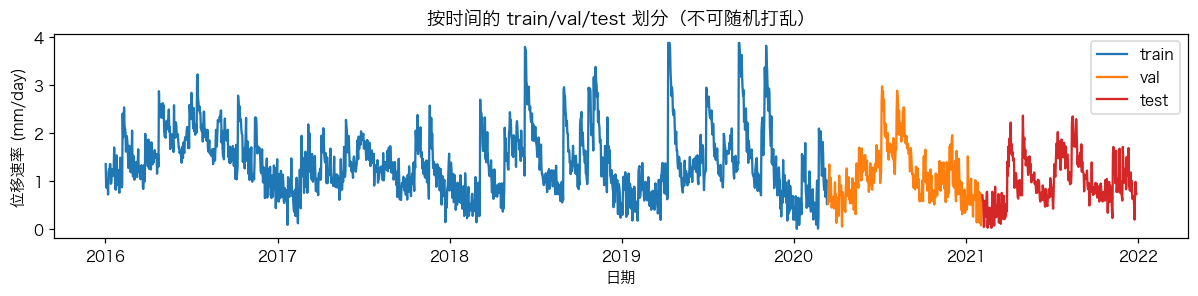

In [7]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = torch.from_numpy(X), torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def make_loader(X, y, batch_size=64, shuffle=False):
    return DataLoader(SeqDataset(X, y), batch_size=batch_size, shuffle=shuffle)

# 时序划分可视化
d = df["date"].to_numpy()
plt.figure(figsize=(11, 2.8))
plt.plot(d[:prep["i_val"]], df[TARGET_COL][:prep["i_val"]], label="train", color="tab:blue")
plt.plot(d[prep["i_val"]:prep["i_test"]], df[TARGET_COL][prep["i_val"]:prep["i_test"]], label="val", color="tab:orange")
plt.plot(d[prep["i_test"]:], df[TARGET_COL][prep["i_test"]:], label="test", color="tab:red")
plt.legend(); plt.ylabel("位移速率 (mm/day)"); plt.xlabel("日期")
plt.title("按时间的 train/val/test 划分（不可随机打乱）")
plt.tight_layout(); plt.show()

## 4. LSTM 原理与 NumPy 从零实现

### 4.1 门控机制

RNN 的梯度沿时间反传时含 $\prod_t \partial h_t/\partial h_{t-1}$ 连乘，长序列下**梯度消失/爆炸**。LSTM 引入细胞状态 $c_t$ 与三个门，让梯度沿 $c_t = f_t\odot c_{t-1} + i_t\odot\tilde c_t$ 的**加法路径**回传：

$$
\begin{aligned}
i_t &= \sigma(W_i x_t + U_i h_{t-1} + b_i) \quad &\text{输入门：写入多少新信息}\\
f_t &= \sigma(W_f x_t + U_f h_{t-1} + b_f) \quad &\text{遗忘门：保留多少旧记忆}\\
o_t &= \sigma(W_o x_t + U_o h_{t-1} + b_o) \quad &\text{输出门：输出多少记忆}\\
\tilde c_t &= \tanh(W_c x_t + U_c h_{t-1} + b_c) \quad &\text{候选记忆}\\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde c_t, \qquad h_t = o_t \odot \tanh(c_t)
\end{aligned}
$$

**对岩土时序的直观解释**：$c_t$ 像"土体记忆"——前期降雨入渗（写入）、缓慢消散（遗忘）、当前变形速率（输出）。

> 实战直接用 `nn.LSTM`（cuDNN/MPS 加速、数值更稳）；从零实现的目的是吃透维度与 BPTT，§4.3 用数值梯度验证正确性。

In [8]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class NumPyLSTM:
    """单层 LSTM 从零实现（前向 + BPTT）。
    输入 (B, T, D)，取最后时刻隐状态经线性层回归输出。
    四门 [i, f, o, g] 参数拼接为 (D, 4H) / (H, 4H)，前向反向都更简洁。"""

    def __init__(self, d, h, seed=0):
        rng = np.random.default_rng(seed)
        self.d, self.h = d, h
        self.Wx = rng.normal(0, np.sqrt(1 / d), (d, 4 * h))
        self.Wh = rng.normal(0, np.sqrt(1 / h), (h, 4 * h))
        self.b = np.zeros(4 * h)
        self.b[h:2 * h] = 1.0          # 遗忘门偏置置 1：训练初期更易保留长程记忆（经典技巧）
        self.Wy = rng.normal(0, np.sqrt(1 / h), (h, 1))
        self.by = np.zeros(1)

    def forward(self, x):
        B, T, _ = x.shape
        h = self.h
        hs = np.zeros((B, T, h)); cs = np.zeros((B, T, h))
        gates = []
        h_prev = np.zeros((B, h)); c_prev = np.zeros((B, h))
        for t in range(T):
            z = x[:, t] @ self.Wx + h_prev @ self.Wh + self.b        # (B, 4H)
            zi, zf, zo, zg = np.split(z, 4, axis=-1)
            i, f, o, g = sigmoid(zi), sigmoid(zf), sigmoid(zo), np.tanh(zg)
            c = f * c_prev + i * g
            hh = o * np.tanh(c)
            gates.append((i, f, o, g, c, c_prev))
            hs[:, t], cs[:, t], h_prev, c_prev = hh, c, hh, c
        self.cache = dict(x=x, hs=hs, cs=cs, gates=gates)
        self.y = hs[:, -1] @ self.Wy + self.by                        # (B, 1)
        return self.y

    def loss(self, y_true):
        self.y_true = y_true
        return float(np.mean((self.y - y_true) ** 2))

    def backward(self):
        """BPTT：解析梯度（链式法则逐时刻反传），供 §4.3 与数值梯度对照。"""
        if not hasattr(self, "y_true"):
            raise RuntimeError("请先调用 forward(x) 与 loss(y_true)，再 backward()")
        x, hs, cs, gates = (self.cache["x"], self.cache["hs"],
                            self.cache["cs"], self.cache["gates"])
        B, T, _ = x.shape
        grads = {k: np.zeros_like(v) for k, v in
                 [("Wx", self.Wx), ("Wh", self.Wh), ("b", self.b), ("Wy", self.Wy), ("by", self.by)]}
        dy = 2.0 * (self.y - self.y_true) / self.y.size               # dL/dŷ（MSE）
        grads["Wy"] = hs[:, -1].T @ dy
        grads["by"] = dy.sum(0)
        dc_next = np.zeros((B, self.h))
        dh_next = np.zeros((B, self.h))
        for t in reversed(range(T)):
            i, f, o, g, c, c_prev = gates[t]
            tanh_c = np.tanh(c)
            dh = dh_next + (dy @ self.Wy.T if t == T - 1 else 0)      # h_t 只经未来时刻与(末时刻的)损失
            dc = dc_next + dh * o * (1 - tanh_c ** 2)                 # 经 h = o·tanh(c)
            do = dh * tanh_c
            di = dc * g
            dg = dc * i
            df = dc * c_prev
            dc_next = dc * f
            dz = np.concatenate([di * i * (1 - i), df * f * (1 - f),
                                 do * o * (1 - o), dg * (1 - g ** 2)], axis=-1)
            grads["Wx"] += x[:, t].T @ dz
            grads["Wh"] += (hs[:, t - 1] if t > 0 else np.zeros((B, self.h))).T @ dz
            grads["b"] += dz.sum(0)
            dh_next = dz @ self.Wh.T
        return grads

In [9]:
def numerical_grads(model, x, y, eps=1e-5):
    """中心差分数值梯度，用于校验 BPTT 实现正确性。"""
    grads = {}
    for name in ["Wx", "Wh", "b", "Wy", "by"]:
        p = getattr(model, name)
        g = np.zeros_like(p)
        it = np.nditer(p, flags=["multi_index"])
        while not it.finished:
            ix = it.multi_index
            orig = p[ix]
            p[ix] = orig + eps; model.forward(x); l1 = model.loss(y)
            p[ix] = orig - eps; model.forward(x); l2 = model.loss(y)
            p[ix] = orig
            g[ix] = (l1 - l2) / (2 * eps)
            it.iternext()
        grads[name] = g
    return grads

rng_np = np.random.default_rng(0)
m = NumPyLSTM(d=3, h=4, seed=0)
x = rng_np.normal(size=(2, 5, 3)); y = rng_np.normal(size=(2, 1))
m.forward(x)
m.loss(y)                # 先计算损失（内部记录 y_true），再反传
g_ana = m.backward()
g_num = numerical_grads(m, x, y)

ok = True
for k in ["Wx", "Wh", "b", "Wy", "by"]:
    denom = np.abs(g_ana[k]) + np.abs(g_num[k]) + 1e-12
    rel = np.max(np.abs(g_ana[k] - g_num[k]) / denom)
    ok &= rel < 1e-5
    print(f"{k:3s} 最大相对误差 = {rel:.2e}")
print("梯度检查：", "✅ 通过，BPTT 实现正确" if ok else "❌ 未通过")

Wx  最大相对误差 = 3.01e-08
Wh  最大相对误差 = 2.19e-07
b   最大相对误差 = 3.87e-09
Wy  最大相对误差 = 2.29e-11
by  最大相对误差 = 8.76e-13
梯度检查： ✅ 通过，BPTT 实现正确


## 5. PyTorch 模型（LSTM / GRU / BiLSTM 可切换）

设计要点：
- **取最后时刻隐状态** `out[:, -1]` 进回归头（也可用 attention 聚合，见 §10.3 展望）；
- `nn.LSTM` 的 `dropout` 只作用于**层与层之间**，单层时自动失效，故输出头里再补一个 Dropout；
- BiLSTM 沿输入窗正反两向编码：用于**一步预测**没有泄漏（窗口内全是历史观测）；
  但不要把"未来已知的多步驱动序列"整段送入后再预测，那会用到未来信息。

In [10]:
class LSTMRegressor(nn.Module):
    """通用序列回归器：LSTM/GRU × 单/双向 × 多层 × Dropout。"""

    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2,
                 horizon=1, bidirectional=False, model_type="lstm"):
        super().__init__()
        Cell = nn.LSTM if model_type == "lstm" else nn.GRU
        self.rnn = Cell(n_features, hidden_size, num_layers,
                        batch_first=True,
                        dropout=dropout if num_layers > 1 else 0.0,
                        bidirectional=bidirectional)
        d_out = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.Linear(d_out, 32), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(32, horizon))
        self.model_name = ("Bi" if bidirectional else "") + model_type.upper()

    def forward(self, x):
        out, _ = self.rnn(x)              # out: (B, T, H·dir)
        return self.head(out[:, -1])      # 最后时刻 → (B, horizon)

model = LSTMRegressor(len(prep["cols"]), hidden_size=64, num_layers=2, dropout=0.2,
                      horizon=HORIZON).to(DEVICE)
print(model.model_name, f"参数量 = {sum(p.numel() for p in model.parameters()):,}")
with torch.no_grad():
    print("前向输出形状:", model(torch.from_numpy(prep["X"][:4]).to(DEVICE)).shape)

LSTM 参数量 = 53,313
前向输出形状: torch.Size([4, 1])


## 6. 训练

| 组件 | 做法 | 作用 |
|---|---|---|
| 优化器 | `AdamW`（带解耦权重衰减） | 自适应步长 + 正则 |
| 早停 | 验证损失 patience 轮不降即停，**回滚到最优权重** | 防过拟合，免调 epoch 数 |
| LR 调度 | `ReduceLROnPlateau`（验证损失平台期减半） | 后期精细收敛 |
| 梯度裁剪 | `clip_grad_norm_(max_norm=5)` | LSTM 防梯度爆炸**标配** |
| 损失 | 标准化空间 MSE（= 相对量纲的误差） | 各变量量纲一致；评估时再反变换回 mm/day |

In [11]:
class EarlyStopping:
    """验证损失 patience 轮不下降(超过 min_delta)则停止，并保存最优权重。"""
    def __init__(self, patience=15, min_delta=1e-5):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.counter, self.best_state = np.inf, 0, None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best, self.counter = val_loss, 0
            self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = nn.functional.mse_loss(model(xb), yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)   # 梯度裁剪
                optimizer.step()
            total += loss.item() * len(xb)
    return total / len(loader.dataset)


def train_model(model, train_loader, val_loader, lr=1e-3, epochs=200,
                patience=20, weight_decay=1e-4, verbose=True):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=max(patience // 3, 2))
    stop = EarlyStopping(patience=patience)
    hist = {"train": [], "val": []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, opt)
        va = run_epoch(model, val_loader)
        sched.step(va)
        hist["train"].append(tr); hist["val"].append(va)
        if verbose and (ep == 1 or ep % 20 == 0):
            print(f"epoch {ep:3d} | train {tr:.4f} | val {va:.4f} | lr {opt.param_groups[0]['lr']:.1e}")
        if stop.step(va, model):
            if verbose:
                print(f"早停于 epoch {ep}，最佳 val loss = {stop.best:.4f}（用时 {time.time()-t0:.1f}s）")
            break
    model.load_state_dict(stop.best_state)     # 回滚到验证最优
    return hist

epoch   1 | train 0.8894 | val 0.4181 | lr 1.0e-03


epoch  20 | train 0.2538 | val 0.2203 | lr 5.0e-04


epoch  40 | train 0.2503 | val 0.1879 | lr 2.5e-04


早停于 epoch 48，最佳 val loss = 0.1869（用时 21.0s）


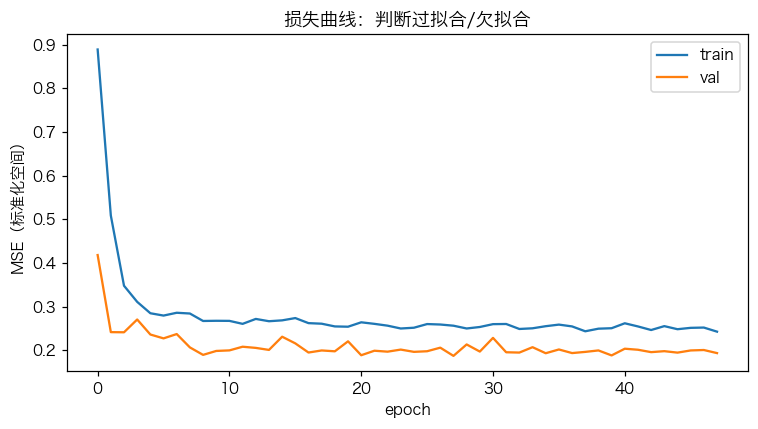

In [12]:
set_seed(SEED)
baseline_model = LSTMRegressor(len(prep["cols"]), hidden_size=64, num_layers=2,
                               dropout=0.2, horizon=HORIZON).to(DEVICE)
hist = train_model(baseline_model,
                   make_loader(prep["X"][prep["m_tr"]], prep["y"][prep["m_tr"]], BATCH_SIZE, shuffle=True),
                   make_loader(prep["X"][prep["m_va"]], prep["y"][prep["m_va"]], 256),
                   lr=1e-3, epochs=150, patience=20)

plt.figure(figsize=(7, 4))
plt.plot(hist["train"], label="train")
plt.plot(hist["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE（标准化空间）"); plt.title("损失曲线：判断过拟合/欠拟合")
plt.legend(); plt.tight_layout(); plt.show()

**读损失曲线**：train ↓ 而 val 回升 → 过拟合（减小模型/加 dropout/加数据）；两者都高 → 欠拟合（加大模型/加长 seq_len/调 lr）。

## 7. 精度检验

**两级评估**（论文建议两级都报告）：
- **速率空间**（建模目标，mm/day）：反映模型本身的拟合能力；
- **累积位移空间**（应用口径，mm）：速率预测逐日累加重构后与实测累积位移比，工程上直接可用。

**指标**（统一在**反归一化后的物理量纲**上计算）：

| 指标 | 公式 | 说明 |
|---|---|---|
| RMSE | $\sqrt{\frac1n\sum (y-\hat y)^2}$ | 对大误差敏感，主流报告口径 |
| MAE | $\frac1n\sum\|y-\hat y\|$ | 对极值稳健 |
| MAPE | $\frac{100\%}{n}\sum\|\frac{y-\hat y}{y}\|$ | 相对误差；目标接近 0 时失真，分母设 0.1 下限 |
| R² / NSE | $1-\frac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2}$ | 同一公式，水文岩土文献常称 NSE（纳什效率系数） |

除全局指标外，建议补充**误差随时间/随预测步长的分布**——岩土风险评价更关心"峰值/突变段预测得准不准"。

In [13]:
RESULTS = []       # 全部实验的 test 指标汇总（速率空间，§10 出总表）
PRED_STORE = {}    # name -> (y_true, y_pred)（速率空间），§10 据此重构累积位移口径

def regression_metrics(y_true, y_pred, name=""):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 0.1, None))) * 100
    r2 = r2_score(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return dict(模型=name, RMSE=rmse, MAE=mae, MAPE_pct=mape, R2=r2, NSE=nse,
                最大误差=np.max(np.abs(y_true - y_pred)))

def register(name, y_true, y_pred):
    row = regression_metrics(y_true, y_pred, name)
    RESULTS.append(row)
    PRED_STORE[name] = (np.asarray(y_true).copy(), np.asarray(y_pred).copy())
    return row

def report(name, y_true, y_pred, record=True):
    row = regression_metrics(y_true, y_pred, name)
    if record:
        row = register(name, y_true, y_pred)
    print(f"[{name}] " + " | ".join(f"{k}={v:.4g}" for k, v in row.items() if k != "模型"))
    return row


SPLIT_KEY = {"train": "tr", "val": "va", "test": "te"}

def true_real(prep_, split="test"):
    """反归一化后的真实目标值（速率, mm/day）。"""
    msk = prep_[f"m_{SPLIT_KEY[split]}"]
    return prep_["y_scaler"].inverse_transform(prep_["y"][msk].reshape(-1, 1)).ravel()


@torch.no_grad()
def predict(model, X, prep_):
    """预测并反归一化到物理量纲 (mm/day)。"""
    model.eval()
    yh = model(torch.from_numpy(X).to(DEVICE)).cpu().numpy()
    return prep_["y_scaler"].inverse_transform(yh)


def rate_to_cum(rate_pred, mask):
    """速率预测 → 累积位移重构：以该段第一天前一日的实测位移为基准逐日累加。"""
    ends_s = prep["ends"][mask]
    disp = df["disp_mm"].to_numpy()
    return disp[ends_s[0] - 1] + np.cumsum(rate_pred)

yte_rate = true_real(prep, "test")
dates_end = df["date"].to_numpy()[prep["ends"]]

In [14]:
# ---------- 基线模型：速率空间三子集指标 ----------
pred_rate_all = predict(baseline_model, prep["X"], prep).ravel()
y_rate_all = prep["y_scaler"].inverse_transform(prep["y"].reshape(-1, 1)).ravel()

for key, label in [("tr", "train"), ("va", "val"), ("te", "test")]:
    msk = prep[f"m_{key}"]
    row = regression_metrics(y_rate_all[msk], pred_rate_all[msk], label)
    print(f"[{label:5s}] RMSE={row['RMSE']:.4f} mm/day | MAE={row['MAE']:.4f} | "
          f"MAPE={row['MAPE_pct']:.2f}% | R2={row['R2']:.4f}")
print()
pred_rate_te = pred_rate_all[prep["m_te"]]
report("LSTM(基线)", yte_rate, pred_rate_te)          # 速率空间 → 计入 §10 汇总

# 重构累积位移口径（应用视角）
cum_true_te = df["disp_mm"].to_numpy()[prep["ends"][prep["m_te"]]]
cum_pred_te = rate_to_cum(pred_rate_te, prep["m_te"])
report("LSTM(基线)·累积重构", cum_true_te, cum_pred_te, record=False)

[train] RMSE=0.3211 mm/day | MAE=0.2170 | MAPE=22.34% | R2=0.7671
[val  ] RMSE=0.2856 mm/day | MAE=0.2246 | MAPE=31.67% | R2=0.7388
[test ] RMSE=0.2595 mm/day | MAE=0.2022 | MAPE=36.40% | R2=0.7186

[LSTM(基线)] RMSE=0.2595 | MAE=0.2022 | MAPE_pct=36.4 | R2=0.7186 | NSE=0.7186 | 最大误差=1.092
[LSTM(基线)·累积重构] RMSE=14.07 | MAE=12.58 | MAPE_pct=0.4673 | R2=0.9817 | NSE=0.9817 | 最大误差=24.05


{'模型': 'LSTM(基线)·累积重构',
 'RMSE': 14.073916204860284,
 'MAE': 12.576534344420669,
 'MAPE_pct': np.float64(0.4672715189325983),
 'R2': 0.981666727928977,
 'NSE': np.float64(0.981666727928977),
 '最大误差': np.float64(24.05116866168828)}

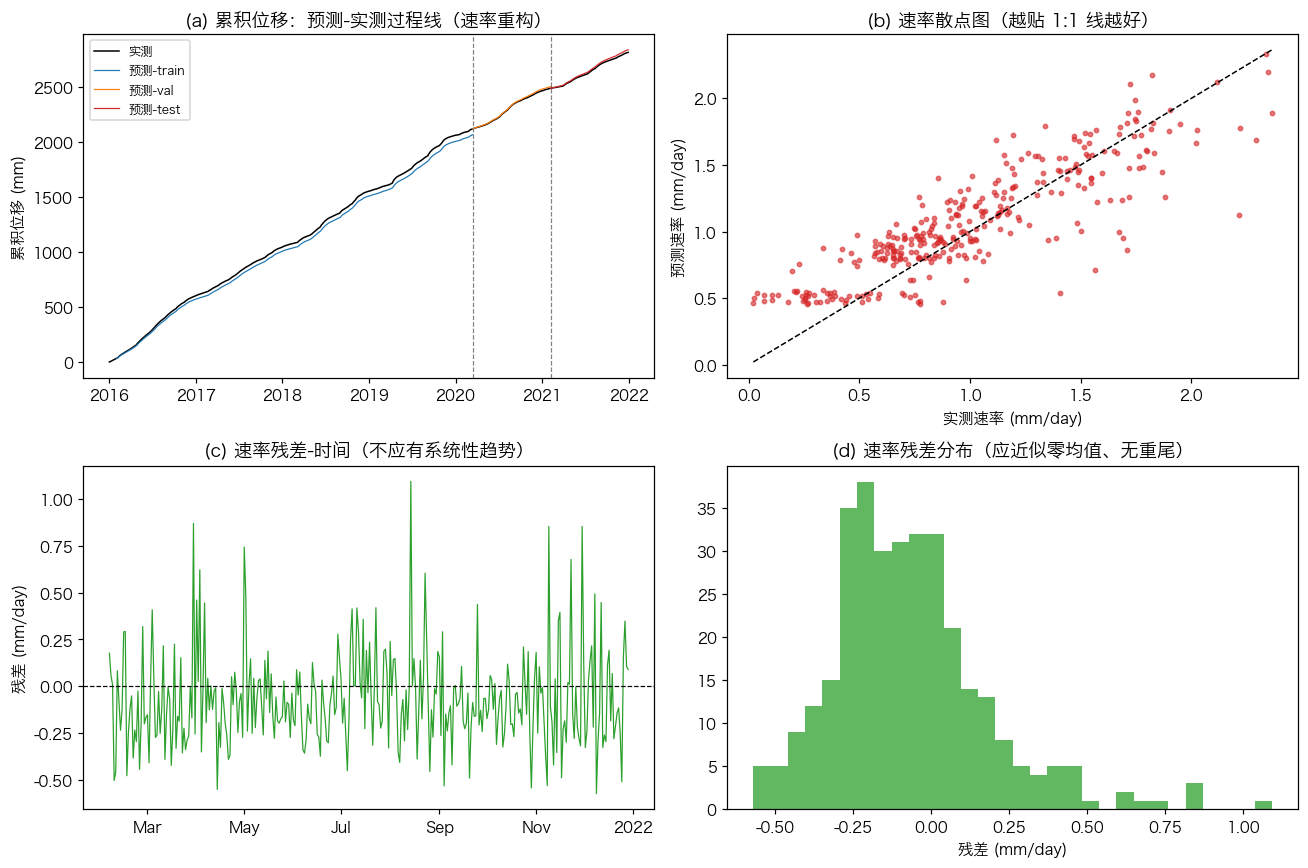

In [15]:
# ---------- 精度检验四联图 ----------
resid_te = yte_rate - pred_rate_te
cum_pred_all_tr = rate_to_cum(pred_rate_all[prep["m_tr"]], prep["m_tr"])
cum_pred_all_va = rate_to_cum(pred_rate_all[prep["m_va"]], prep["m_va"])
disp_true_tr = df["disp_mm"].to_numpy()[prep["ends"][prep["m_tr"]]]
disp_true_va = df["disp_mm"].to_numpy()[prep["ends"][prep["m_va"]]]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(df.date, df["disp_mm"], lw=1, color="k", label="实测")
ax.plot(dates_end[prep["m_tr"]], cum_pred_all_tr, lw=.8, color="tab:blue", label="预测-train")
ax.plot(dates_end[prep["m_va"]], cum_pred_all_va, lw=.8, color="tab:orange", label="预测-val")
ax.plot(dates_end[prep["m_te"]], cum_pred_te, lw=.8, color="tab:red", label="预测-test")
for x0 in [df.date.iloc[prep["i_val"]], df.date.iloc[prep["i_test"]]]:
    ax.axvline(x0, color="gray", ls="--", lw=.8)
ax.set_title("(a) 累积位移：预测-实测过程线（速率重构）")
ax.set_ylabel("累积位移 (mm)"); ax.legend(fontsize=8)
fix_date_axis(ax)

ax = axes[0, 1]
ax.scatter(yte_rate, pred_rate_te, s=8, alpha=.6, color="tab:red")
lims = [min(yte_rate.min(), pred_rate_te.min()), max(yte_rate.max(), pred_rate_te.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("实测速率 (mm/day)"); ax.set_ylabel("预测速率 (mm/day)")
ax.set_title("(b) 速率散点图（越贴 1:1 线越好）")

ax = axes[1, 0]
ax.plot(dates_end[prep["m_te"]], resid_te, lw=.8, color="tab:green")
ax.axhline(0, color="k", ls="--", lw=.8)
ax.set_title("(c) 速率残差-时间（不应有系统性趋势）"); ax.set_ylabel("残差 (mm/day)")
fix_date_axis(ax)

ax = axes[1, 1]
ax.hist(resid_te, bins=30, color="tab:green", alpha=.75)
ax.set_title("(d) 速率残差分布（应近似零均值、无重尾）"); ax.set_xlabel("残差 (mm/day)")

plt.tight_layout(); plt.show()

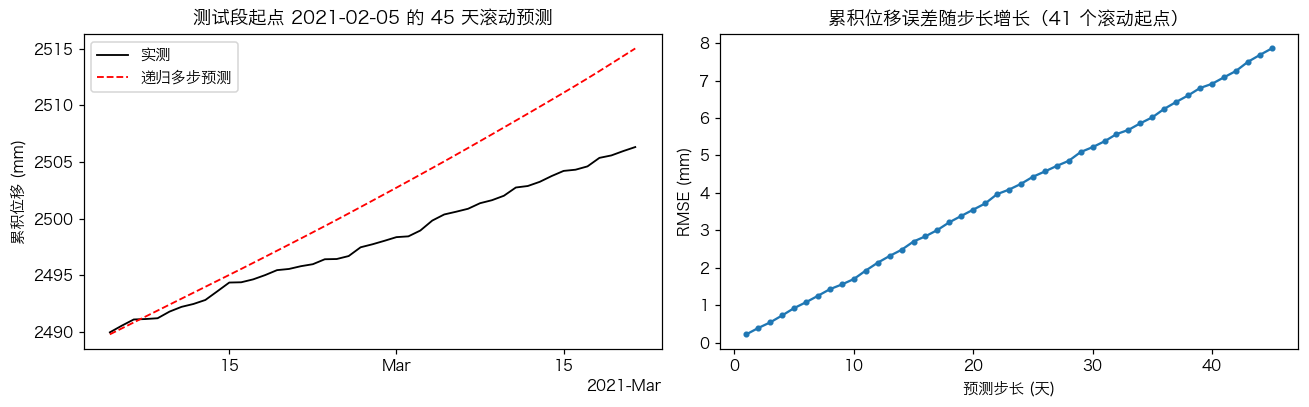

递归预测累积位移 RMSE：步长1 = 0.22 mm，步长30 = 5.22 mm


In [16]:
@torch.no_grad()
def recursive_forecast(model, prep_, origin, n_steps):
    """自 origin 时刻起滚动预测未来 n_steps 天：先预测逐日速率（预测值回填输入，自回归递归），
    再重构累积位移。假设未来驱动(降雨/水位/温度)由气象水文预报或情景给出（此处用合成数据真值代替）。"""
    model.eval()
    Xf = prep_["Xfull"]                       # (n, F) 完整标准化时间序列（按"时间"取窗，而非滑窗样本）
    disp_idx = prep_["cols"].index(TARGET_COL)
    win = Xf[origin - SEQ_LEN:origin].copy()
    preds = []
    for k in range(n_steps):
        p = float(model(torch.from_numpy(win[None]).to(DEVICE)))
        preds.append(p)
        new_row = Xf[origin + k].copy()      # 该行含"未来真实速率"，必须替换
        new_row[disp_idx] = p                # 输入/输出同一标准化，可直接回填
        win = np.vstack([win[1:], new_row[None]])
    rate = prep_["y_scaler"].inverse_transform(np.array(preds).reshape(-1, 1)).ravel()
    disp0 = df["disp_mm"].to_numpy()[origin - 1]
    return rate, disp0 + np.cumsum(rate)


# 单一起点示例 + 误差随步长增长（多起点统计，累积位移口径）
N_STEPS = 45
origin0 = prep["i_test"]
_, fc_cum = recursive_forecast(baseline_model, prep, origin0, N_STEPS)
truth0 = df["disp_mm"].to_numpy()[origin0:origin0 + N_STEPS]
dates0 = df["date"].to_numpy()[origin0:origin0 + N_STEPS]

n_origins = 0
sq_err = np.zeros(N_STEPS)
for o in range(prep["i_test"], prep["n"] - N_STEPS, 7):
    _, cum_o = recursive_forecast(baseline_model, prep, o, N_STEPS)
    sq_err += (cum_o - df["disp_mm"].to_numpy()[o:o + N_STEPS]) ** 2
    n_origins += 1
rmse_curve = np.sqrt(sq_err / n_origins)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(dates0, truth0, "k-", lw=1.2, label="实测")
axes[0].plot(dates0, fc_cum, "r--", lw=1.2, label="递归多步预测")
axes[0].set_title(f"测试段起点 {pd.Timestamp(dates0[0]).date()} 的 {N_STEPS} 天滚动预测")
axes[0].set_ylabel("累积位移 (mm)"); axes[0].legend()
fix_date_axis(axes[0], max_ticks=6)
axes[1].plot(range(1, N_STEPS + 1), rmse_curve, "o-", ms=3)
axes[1].set_xlabel("预测步长 (天)"); axes[1].set_ylabel("RMSE (mm)")
axes[1].set_title(f"累积位移误差随步长增长（{n_origins} 个滚动起点）")
plt.tight_layout(); plt.show()
print(f"递归预测累积位移 RMSE：步长1 = {rmse_curve[0]:.2f} mm，步长30 = {rmse_curve[29]:.2f} mm")

## 8. 调参

### 8.1 超参数清单（按重要性）

| 超参数 | 重要性 | 建议范围 | 经验法则 |
|---|---|---|---|
| learning_rate | ★★★ | 3e-4 ~ 3e-3（Adam 系） | **最先调**；loss 震荡→降，平台不动→升 |
| seq_len（窗口） | ★★★ | 覆盖 1~2 个主导周期 | 结合降雨-位移**互相关滞后分析**选取 |
| hidden_size | ★★★ | 16 ~ 256 | 样本 < 1 千条用 16~64，**小数据配小模型** |
| num_layers | ★★ | 1 ~ 3 | 小数据 1~2 层足够，更深易过拟合 |
| dropout | ★★ | 0 ~ 0.5 | 过拟合时加；仅层间生效 |
| batch_size | ★★ | 16 ~ 128 | 大 batch 稳、小 batch 泛化略好 |
| 梯度裁剪 max_norm | ★★ | 1 ~ 5 | LSTM 防爆梯度标配 |
| weight_decay | ★ | 1e-5 ~ 1e-3 | 与 AdamW 配套 |

### 8.2 调参心法
1. 先跑通默认配置，看 train/val 差距判断**过拟合/欠拟合方向**，再决定往哪调；
2. **一次只动一组参数**，固定随机种子与数据划分，否则噪声淹没差异；
3. 模型选择只看 **val**；**test 只在最终评估时碰一次**（反复看 test = 变相过拟合）；
4. 高维空间**随机搜索 ≥ 网格搜索**；预算充足用 Optuna（TPE 贝叶斯）；
5. 搜索会"过拟合验证集"——试验次数越多，test 与 val 的差距越可能拉大，结论要留余地。

In [17]:
def fit_eval(name, cfg, prep_, epochs=150, patience=20, split="test", record=True, seed=SEED):
    """按配置训练并在指定子集(物理量纲)评估；record=True 时计入 §10 汇总表。"""
    set_seed(seed)
    model = LSTMRegressor(len(prep_["cols"]),
                          hidden_size=cfg["hidden"], num_layers=cfg["layers"],
                          dropout=cfg["dropout"], horizon=cfg.get("horizon", HORIZON),
                          bidirectional=cfg.get("bidir", False),
                          model_type=cfg.get("cell", "lstm")).to(DEVICE)
    train_model(model,
                make_loader(prep_["X"][prep_["m_tr"]], prep_["y"][prep_["m_tr"]],
                            cfg.get("batch", BATCH_SIZE), shuffle=True),
                make_loader(prep_["X"][prep_["m_va"]], prep_["y"][prep_["m_va"]], 256),
                lr=cfg["lr"], epochs=epochs, patience=patience, verbose=False)
    msk = prep_[f"m_{SPLIT_KEY[split]}"]
    pred = predict(model, prep_["X"][msk], prep_).ravel()
    ytrue = true_real(prep_, split)
    row = regression_metrics(ytrue, pred, name)
    if record:
        RESULTS.append(row)
        PRED_STORE[name] = (ytrue.copy(), pred.copy())
    return model, pred, row

DEFAULT_CFG = dict(hidden=64, layers=2, dropout=0.2, lr=1e-3, batch=BATCH_SIZE)

In [18]:
# ---------- 8.3 随机搜索（在 val 上选型）----------
space_rng = np.random.default_rng(1)
SPACE = dict(hidden=[32, 64, 128], layers=[1, 2], dropout=[0.0, 0.2, 0.4],
             lr=[3e-4, 1e-3, 3e-3], batch=[32, 64])
N_TRIAL, EPOCHS_SEARCH = 12, 60      # 演示用小预算；正式研究建议 ≥ 50 trials × 200 epochs

t0 = time.time()
rows = []
for k in range(N_TRIAL):
    cfg = {p: space_rng.choice(v).item() for p, v in SPACE.items()}
    _, _, r = fit_eval(f"trial{k}", cfg, prep, epochs=EPOCHS_SEARCH, split="val", record=False)
    rows.append({**cfg, "val_RMSE": r["RMSE"]})
    print(f"trial {k:2d} | {cfg} | val RMSE = {r['RMSE']:.4f} mm/day   (累计 {time.time()-t0:.0f}s)")

search_df = pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)
print("\n验证集 Top-5：")
search_df.head()

trial  0 | {'hidden': 64, 'layers': 2, 'dropout': 0.4, 'lr': 0.003, 'batch': 32} | val RMSE = 0.2860 mm/day   (累计 13s)


trial  1 | {'hidden': 32, 'layers': 2, 'dropout': 0.4, 'lr': 0.0003, 'batch': 32} | val RMSE = 0.2928 mm/day   (累计 28s)


trial  2 | {'hidden': 128, 'layers': 1, 'dropout': 0.0, 'lr': 0.003, 'batch': 32} | val RMSE = 0.2834 mm/day   (累计 47s)


trial  3 | {'hidden': 64, 'layers': 2, 'dropout': 0.2, 'lr': 0.0003, 'batch': 32} | val RMSE = 0.2874 mm/day   (累计 78s)


trial  4 | {'hidden': 128, 'layers': 2, 'dropout': 0.4, 'lr': 0.001, 'batch': 64} | val RMSE = 0.2855 mm/day   (累计 107s)


...

trial  8 | {'hidden': 32, 'layers': 2, 'dropout': 0.0, 'lr': 0.0003, 'batch': 32} | val RMSE = 0.2872 mm/day   (累计 152s)


trial  9 | {'hidden': 64, 'layers': 1, 'dropout': 0.4, 'lr': 0.003, 'batch': 64} | val RMSE = 0.2821 mm/day   (累计 159s)


trial 10 | {'hidden': 32, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch': 64} | val RMSE = 0.2844 mm/day   (累计 168s)


trial 11 | {'hidden': 32, 'layers': 2, 'dropout': 0.0, 'lr': 0.0003, 'batch': 64} | val RMSE = 0.2886 mm/day   (累计 179s)

验证集 Top-5：


,hidden,layers,dropout,lr,batch,val_RMSE
0,64,2,0.0,0.001,32,0.281917
1,64,1,0.4,0.003,64,0.282117
2,128,1,0.0,0.003,32,0.283397
3,32,2,0.0,0.001,64,0.284407
4,128,2,0.4,0.001,64,0.285468


In [19]:
# 最优配置回训（更长 epochs），test 只评这一次
best_cfg = {p: (int(search_df.iloc[0][p]) if p in ("hidden", "layers", "batch") else float(search_df.iloc[0][p]))
            for p in SPACE}
print("最优配置:", best_cfg)
tuned_model, _, _ = fit_eval("LSTM(调参后)", best_cfg, prep, epochs=200)
pd.DataFrame(RESULTS)

最优配置: {'hidden': 64, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch': 32}


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,LSTM(基线),0.259503,0.202229,36.403591,0.718556,0.718556,1.092442
1,LSTM(调参后),0.257048,0.200159,36.073956,0.723857,0.723857,1.097919


In [20]:
# ---------- 8.4 Optuna 贝叶斯调参（可选）----------
# pip install optuna 后可运行；TPE 比随机搜索的样本效率更高
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        cfg = dict(hidden=trial.suggest_categorical("hidden", [32, 64, 128]),
                   layers=trial.suggest_int("layers", 1, 2),
                   dropout=trial.suggest_float("dropout", 0.0, 0.5, step=0.1),
                   lr=trial.suggest_float("lr", 3e-4, 3e-3, log=True),
                   batch=trial.suggest_categorical("batch", [32, 64]))
        _, _, r = fit_eval("optuna", cfg, prep, epochs=60, split="val", record=False)
        return r["RMSE"]

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=12)
    print("最优参数:", study.best_params, "| val RMSE =", f"{study.best_value:.4f} mm/day")
except ImportError:
    print("未安装 optuna（pip install optuna），此处代码供参考")

未安装 optuna（pip install optuna），此处代码供参考


## 9. 改进方向

| 路线 | 手段 | 本 Notebook |
|---|---|---|
| 目标与分解策略 | 累积位移直接预测 / 趋势-残差分解 / 速率-重构 | §9.1 三种处理对比 |
| 模型结构 | GRU / BiLSTM / Attention / TCN / Transformer | §9.2 对比 |
| **物理融合** | 物理引导特征；机理模型软约束损失（你的课题核心） | §9.3 实现 |
| 不确定性 | MC Dropout / Deep Ensemble / Conformal | §9.4 实现 |
| 稳定性 | 多种子集成（降低初始化方差） | §9.5 实现 |

### 9.1 累积位移的三种处理对比（含一个重要的反例）

| 方案 | 做法 | 预期 |
|---|---|---|
| (a) 直接预测累积位移 | 目标 = $D_t$ | ❌ 累积位移非平稳，测试段超出训练范围，模型无法外推 → **反例** |
| (b) 趋势-残差分解 | $D_t = g(t) + \text{LSTM残差}$，趋势仅用训练段拟合 | ⚠️ 经典范式，但趋势外推形式是软肋 |
| (c) 速率-重构（主方案） | 预测 $\Delta D_t$ 再累加 | ✅ 一阶差分自动处理趋势，通常最稳健 |

三个方案统一在**累积位移口径**（mm）下比较。

三种处理在【累积位移口径】下的测试集对比：


,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
模型,,,,,,
(a) 直接预测累积,389.612,376.976,14.134,-13.050,-13.050,531.581
(b) 趋势-残差分解,126.542,121.859,4.567,-0.482,-0.482,182.363
(c) 速率-重构(主方案),14.074,12.577,0.467,0.982,0.982,24.051


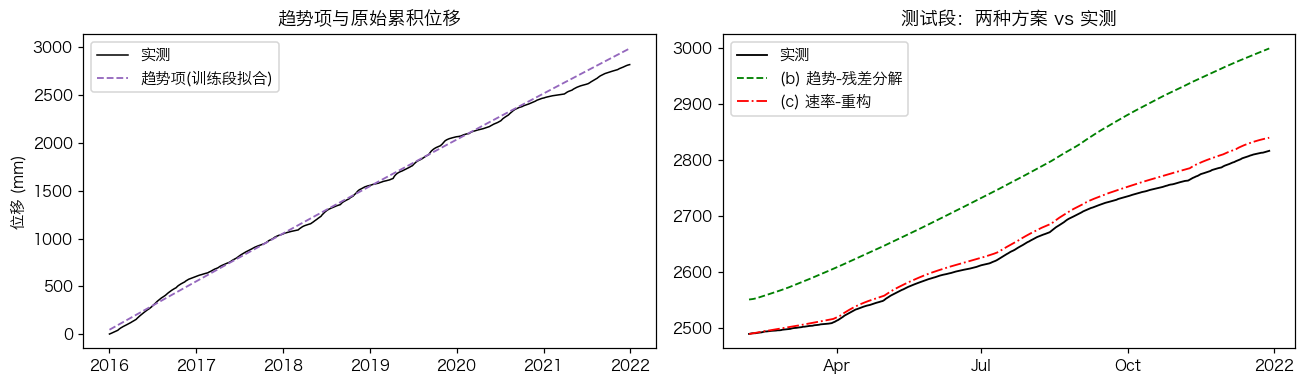

In [21]:
disp_arr = df["disp_mm"].to_numpy()
ends_te = prep["ends"][prep["m_te"]]
cum_true_te = disp_arr[ends_te]
cum_rate_row = regression_metrics(cum_true_te, rate_to_cum(pred_rate_te, prep["m_te"]),
                                  "(c) 速率-重构(主方案)")

# ---- (a) 直接预测累积位移（反例）----
prep_cum = build_arrays(df, ["rainfall_mm", "reservoir_m", "temp_c", "disp_mm"], "disp_mm")
_, _, row_a = fit_eval("(a) 直接预测累积", best_cfg, prep_cum, epochs=150, record=False)

# ---- (b) 趋势-残差分解：趋势只用训练段拟合（二次多项式，实际可用指数/样条/STL）----
tt = np.arange(prep["n"])
trend_coef = np.polyfit(tt[:prep["i_val"]], disp_arr[:prep["i_val"]], deg=2)
trend = np.polyval(trend_coef, tt)
df_dec = df.copy()
df_dec["trend_mm"], df_dec["resid_mm"] = trend, disp_arr - trend
prep_dec = build_arrays(df_dec, ["rainfall_mm", "reservoir_m", "temp_c", "disp_mm", "trend_mm"],
                        "resid_mm")
model_dec, pred_resid_te, _ = fit_eval("(b) 趋势-残差分解", best_cfg, prep_dec,
                                       epochs=150, record=False)
cum_pred_dec = trend[ends_te] + pred_resid_te.ravel()   # fit_eval 返回的已是残差物理量纲(mm)
row_b = regression_metrics(cum_true_te, cum_pred_dec, "(b) 趋势-残差分解")

cmp_df = pd.DataFrame([row_a, row_b, cum_rate_row]).set_index("模型")
print("三种处理在【累积位移口径】下的测试集对比：")
from IPython.display import display
display(cmp_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(df.date, disp_arr, lw=1, color="k", label="实测")
axes[0].plot(df.date, trend, lw=1.2, color="tab:purple", ls="--", label="趋势项(训练段拟合)")
axes[0].set_title("趋势项与原始累积位移"); axes[0].set_ylabel("位移 (mm)"); axes[0].legend()
axes[1].plot(df.date.iloc[ends_te], cum_true_te, "k-", lw=1.2, label="实测")
axes[1].plot(df.date.iloc[ends_te], cum_pred_dec, "g--", lw=1.2, label="(b) 趋势-残差分解")
axes[1].plot(df.date.iloc[ends_te], rate_to_cum(pred_rate_te, prep["m_te"]), "r-.", lw=1.2, label="(c) 速率-重构")
axes[1].set_title("测试段：两种方案 vs 实测"); axes[1].legend()
fix_date_axis(axes[1], max_ticks=6)
plt.tight_layout(); plt.show()

In [22]:
# ---------- 9.2 模型结构对比（速率空间） ----------
for vname, cell_type, bidir in [("GRU", "gru", False), ("BiLSTM", "lstm", True)]:
    fit_eval(vname, {**best_cfg, "cell": cell_type, "bidir": bidir}, prep, epochs=200)
pd.DataFrame(RESULTS)

,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,LSTM(基线),0.259503,0.202229,36.403591,0.718556,0.718556,1.092442
1,LSTM(调参后),0.257048,0.200159,36.073956,0.723857,0.723857,1.097919
2,GRU,0.259843,0.202499,36.698551,0.717819,0.717819,1.075281
3,BiLSTM,0.255354,0.195856,32.847569,0.727485,0.727485,1.092153


### 9.3 物理融合（面向数据-物理驱动风险评估）

**损失级融合的最小实现**：机理侧先率定一个低维物理模型描述**位移速率**（蠕变衰减 + 有效降雨一阶响应 + 库水位骤降响应，系数仅用训练段最小二乘率定）：

$$v^{phys}_t = a_0 + a_1 e^{-t/T} + a_2 R^{eff}_t + a_3 \max(0, -\Delta L_t) \quad \text{(率定)}$$

融合训练：$\mathcal{L} = \underbrace{\text{MSE}(\hat v, v)}_{\text{数据项}} + \lambda\,\underbrace{\text{MSE}(\hat v, v^{phys})}_{\text{物理项}}$

- $\lambda$ 在**验证集**上选择：太小 = 无融合，太大 = 被粗糙机理模型拖累（下方做了敏感性扫描）；
- 课题落地时，$v^{phys}$ 可替换为**渗流/固结/极限平衡等数值模型的输出**，或把物理约束写成方程残差（PINN 式）；
- 另一条更轻量的路线是**物理引导特征**：把有效降雨 $R^{eff}$（上文已计算）直接作为输入特征。

机理模型率定系数: [-3.377e-01  3.000e-04  1.109e+00  1.229e-01  9.468e-01]
[机理模型(仅物理)] test RMSE = 0.4239 mm/day


λ = 0.0 | val RMSE = 0.2819 | test RMSE = 0.2570 mm/day


λ = 0.1 | val RMSE = 0.2831 | test RMSE = 0.2581 mm/day


λ = 0.3 | val RMSE = 0.2863 | test RMSE = 0.2614 mm/day


λ = 1.0 | val RMSE = 0.2935 | test RMSE = 0.2579 mm/day


λ = 3.0 | val RMSE = 0.3051 | test RMSE = 0.2670 mm/day


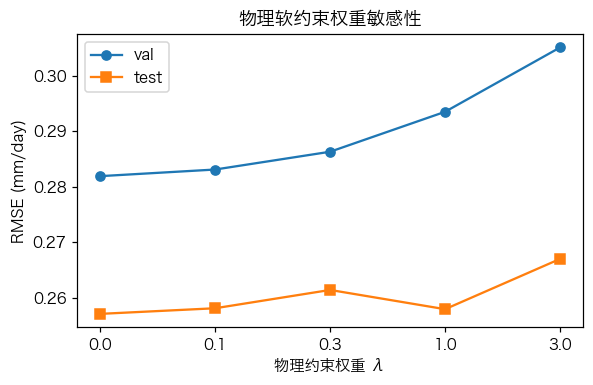

In [23]:
def eff_rainfall(rain, tau=12.0, K=60):
    """一阶指数滞后核的有效降雨。τ 可在训练段用互相关/优化率定，此处取演示值。"""
    w = np.exp(-np.arange(K) / tau); w /= w.sum()
    return np.convolve(rain, w, mode="full")[:len(rain)]

er = eff_rainfall(df["rainfall_mm"].to_numpy())
dd = np.clip(-np.gradient(df["reservoir_m"].to_numpy()), 0, None)   # 库水位日降幅(仅取骤降)
A = np.stack([np.ones(prep["n"]), tt, np.exp(-tt / 650.0), er, dd], axis=1)   # [1, t, 蠕变衰减, 有效降雨, 骤降]
ends_all = prep["ends"]
coef_phys, *_ = np.linalg.lstsq(A[ends_all[prep["m_tr"]]], true_real(prep, "train"), rcond=None)
y_phys = A @ coef_phys
y_phys_scaled = prep["y_scaler"].transform(y_phys.reshape(-1, 1)).astype("float32").ravel()

# 机理模型自身在速率空间的参考精度（它将作为软约束的"锚"）
phys_row = regression_metrics(true_real(prep, "test"), y_phys[ends_te], "机理模型(仅物理)")
print("机理模型率定系数:", np.round(coef_phys, 4))
print(f"[机理模型(仅物理)] test RMSE = {phys_row['RMSE']:.4f} mm/day")


class PhysDataset(Dataset):
    """额外携带物理模型预测 v_phys 的数据集。"""
    def __init__(self, X, y, yphys):
        self.X, self.y, self.p = (torch.from_numpy(X), torch.from_numpy(y),
                                  torch.from_numpy(yphys.astype("float32")))
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.p[i]


def train_phys(cfg, lam, epochs=100, patience=15):
    """L = MSE(pred, v) + λ·MSE(pred, v_phys)，其余训练细节与 §6 一致。"""
    set_seed(SEED)
    model = LSTMRegressor(len(prep["cols"]), hidden_size=cfg["hidden"], num_layers=cfg["layers"],
                          dropout=cfg["dropout"]).to(DEVICE)
    tl = DataLoader(PhysDataset(prep["X"][prep["m_tr"]], prep["y"][prep["m_tr"]],
                                y_phys_scaled[ends_all[prep["m_tr"]]][:, None]),
                    batch_size=cfg["batch"], shuffle=True)
    vl = make_loader(prep["X"][prep["m_va"]], prep["y"][prep["m_va"]], 256)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    stop = EarlyStopping(patience=patience)
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb, pb in tl:
            xb, yb, pb = xb.to(DEVICE), yb.to(DEVICE), pb.to(DEVICE)
            pred = model(xb)
            loss = nn.functional.mse_loss(pred, yb) + lam * nn.functional.mse_loss(pred, pb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        va = run_epoch(model, vl)
        if stop.step(va, model):
            break
    model.load_state_dict(stop.best_state)
    return model

# λ 敏感性扫描（机理模型越可靠，可用越大的 λ）
lam_list = [0.0, 0.1, 0.3, 1.0, 3.0]
rmse_l, val_rmse_l, phys_models = [], [], {}
for lam in lam_list:
    phys_models[lam] = train_phys(best_cfg, lam)
    p_te = predict(phys_models[lam], prep["X"][prep["m_te"]], prep).ravel()
    p_va = predict(phys_models[lam], prep["X"][prep["m_va"]], prep).ravel()
    rmse_l.append(math.sqrt(mean_squared_error(yte_rate, p_te)))
    val_rmse_l.append(math.sqrt(mean_squared_error(true_real(prep, "val"), p_va)))
    print(f"λ = {lam:3.1f} | val RMSE = {val_rmse_l[-1]:.4f} | test RMSE = {rmse_l[-1]:.4f} mm/day")

register("LSTM+物理软约束(λ=0.3)", yte_rate,
         predict(phys_models[0.3], prep["X"][prep["m_te"]], prep).ravel())

xi = range(len(lam_list))
plt.figure(figsize=(5.5, 3.6))
plt.plot(xi, val_rmse_l, "o-", label="val")
plt.plot(xi, rmse_l, "s-", label="test")
plt.xticks(xi, [str(l) for l in lam_list])
plt.xlabel("物理约束权重 λ"); plt.ylabel("RMSE (mm/day)")
plt.title("物理软约束权重敏感性"); plt.legend(); plt.tight_layout(); plt.show()

### 9.4 不确定性量化（风险评估直接可用）

深度点预测给不出"风险"。**MC Dropout**：预测时保持 Dropout 激活、采样 $N$ 次取均值与标准差 → 近似贝叶斯后验的预测区间（代价近零）。风险评估可直接把区间宽度转化为风险指标。

- **PICP**（区间覆盖率，95% 区间应 ≈ 0.95）：覆盖率过低 = 过于自信，过高 = 区间无信息；
- 更严谨的方案：Deep Ensemble、Conformal Prediction、分位数回归。

PICP(95%区间覆盖率) = 0.378（理想 ≈ 0.95） | PINAW(平均区间宽度/量程) = 0.1123


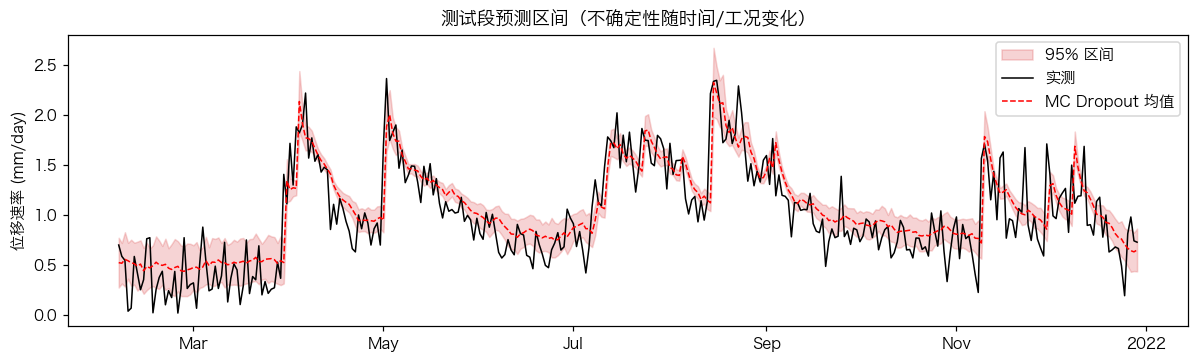

In [24]:
@torch.no_grad()
def mc_dropout_predict(model, X, n_samples=60):
    """预测时保持 dropout 激活，采样 n 次 → 均值与标准差（标准化空间）。"""
    model.train()                      # 打开 dropout（本模型无 BN，安全）
    outs = [model(torch.from_numpy(X).to(DEVICE)).cpu().numpy() for _ in range(n_samples)]
    model.eval()
    return np.mean(outs, axis=0), np.std(outs, axis=0)

mean_s, std_s = mc_dropout_predict(baseline_model, prep["X"][prep["m_te"]], n_samples=60)
scale = prep["y_scaler"].scale_[0]
mu = prep["y_scaler"].inverse_transform(mean_s).ravel()
sd = std_s.ravel() * scale
lo, hi = mu - 1.96 * sd, mu + 1.96 * sd

picp = np.mean((yte_rate >= lo) & (yte_rate <= hi))
pinaw = np.mean(hi - lo) / (yte_rate.max() - yte_rate.min())
print(f"PICP(95%区间覆盖率) = {picp:.3f}（理想 ≈ 0.95） | PINAW(平均区间宽度/量程) = {pinaw:.4f}")

plt.figure(figsize=(11, 3.4))
plt.fill_between(dates_end[prep["m_te"]], lo, hi, color="tab:red", alpha=.2, label="95% 区间")
plt.plot(dates_end[prep["m_te"]], yte_rate, "k-", lw=1, label="实测")
plt.plot(dates_end[prep["m_te"]], mu, "r--", lw=1, label="MC Dropout 均值")
plt.ylabel("位移速率 (mm/day)"); plt.title("测试段预测区间（不确定性随时间/工况变化）")
plt.legend(); fix_date_axis(plt.gca()); plt.tight_layout(); plt.show()

In [25]:
# ---------- 9.5 多种子集成 ----------
preds_ens = []
for s in [0, 1, 2]:
    _, p_s, _ = fit_eval(f"ensemble-seed{s}", best_cfg, prep, epochs=150, record=False, seed=s)
    preds_ens.append(p_s)
pred_ens = np.mean(preds_ens, axis=0)
report("LSTM×3 集成", yte_rate, pred_ens)

[LSTM×3 集成] RMSE=0.2562 | MAE=0.198 | MAPE_pct=35.12 | R2=0.7257 | NSE=0.7257 | 最大误差=1.099


{'模型': 'LSTM×3 集成',
 'RMSE': 0.2561904425143772,
 'MAE': 0.1979571133852005,
 'MAPE_pct': np.float32(35.11982),
 'R2': 0.725696325302124,
 'NSE': np.float32(0.7256963),
 '最大误差': np.float32(1.0986892)}

## 10. 结果汇总与接入真实数据

### 10.1 全部实验汇总

**表 1｜速率空间**（建模目标，mm/day）——反映各方法的拟合能力：

In [26]:
summary = pd.DataFrame(RESULTS).drop_duplicates(subset="模型", keep="last").reset_index(drop=True)
summary.round(4)
summary.to_csv("lstm_results_summary.csv", index=False)
print("已保存 lstm_results_summary.csv")
summary.round(4)

已保存 lstm_results_summary.csv


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,LSTM(基线),0.2595,0.2022,36.403599,0.7186,0.7186,1.0924
1,LSTM(调参后),0.2570,0.2002,36.074001,0.7239,0.7239,1.0979
2,GRU,0.2598,0.2025,36.698601,0.7178,0.7178,1.0753
3,BiLSTM,0.2554,0.1959,32.847599,0.7275,0.7275,1.0922
4,LSTM+物理软约束(λ=0.3),0.2614,0.2066,37.231701,0.7145,0.7145,1.0631
5,LSTM×3 集成,0.2562,0.1980,35.119801,0.7257,0.7257,1.0987


**表 2｜累积位移口径**（应用视角，mm）——由表 1 的速率预测逐日重构而来，工程直接可用：

In [27]:
cum_rows = []
for name, (yt_r, yp_r) in PRED_STORE.items():
    cum_rows.append(regression_metrics(disp_arr[ends_te],
                                       disp_arr[ends_te[0] - 1] + np.cumsum(yp_r), name))
cum_summary = pd.DataFrame(cum_rows).round(3)
cum_summary.to_csv("lstm_results_summary_cumulative.csv", index=False)
cum_summary

,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,LSTM(基线),14.074,12.577,0.467,0.982,0.982,24.051
1,LSTM(调参后),13.379,12.015,0.447,0.983,0.983,20.920
2,GRU,14.857,13.534,0.504,0.980,0.980,21.303
3,BiLSTM,9.473,8.045,0.298,0.992,0.992,15.304
4,LSTM+物理软约束(λ=0.3),17.749,15.668,0.581,0.971,0.971,28.589
5,LSTM×3 集成,12.846,11.498,0.427,0.985,0.985,20.363


### 10.2 接入真实数据 Checklist

1. ✅ CSV 放入本目录：时间列 + 驱动列 + 目标列（等间隔、缺测已插值）；
2. ✅ 改 §2.2 配置区：`DATA_PATH / FEATURE_COLS / TARGET_COL`，位移类目标先做一阶差分得到速率列；
3. ✅ `SEQ_LEN` 用**降雨(驱动)-位移互相关滞后分析**确定，取覆盖 1~2 个主导周期的长度；
4. ✅ 先跑基线 → 看损失曲线定过拟合/欠拟合方向 → §8 随机搜索/Optuna；
5. ✅ 数据量 < 1 千条：hidden ≤ 64、layers ≤ 2、加大 dropout，并优先用 §9.5 集成；
6. ✅ 论文口径：速率空间 + 累积重构空间两级都报告，附预测过程线 + 散点图；
7. ✅ 风险评估：加 §9.4 区间预测，把区间宽度/超越概率接入风险矩阵。

### 10.3 物理融合的进阶路线（与算法②⑥衔接）

| 层级 | 做法 | 关键词 |
|---|---|---|
| 特征级 | 有效降雨、水位变率、库水-位移滞后特征作为输入 | physics-guided features |
| 损失级 | 机理模型输出/方程残差作为软约束（§9.3 模板） | PINN, physics-constrained loss |
| 结构级 | 机理模块与数据模块串/并联（如渗流模型输出作为 LSTM 输入或先验） | hybrid physics-data model |
| 不确定性 | 物理参数先验 + 贝叶斯深度学习 → 风险概率化 | Bayesian DL, reliability |

**常见坑速查**：随机打乱划分 ❌｜全量数据 fit scaler ❌｜直接预测持续增长的累积值 ❌｜MAPE 用于近零目标 ❌｜BiLSTM 混入未来驱动序列 ❌｜test 反复调参 ❌｜MinMax 遇超范围极值 ❌